In [1]:
# 1. Initialize Random Seed

import numpy as np

roll_number = 8025320114
valid_seed = roll_number % (2**32)

rng = np.random.default_rng(valid_seed)

sales_data = rng.integers(1000, 5000, size=(12, 4))

print(sales_data)


[[2898 2154 2236 2926]
 [2034 1364 3274 4829]
 [3329 1844 2417 3400]
 [4829 3446 3185 1399]
 [4209 3980 3691 3406]
 [4397 2309 4471 2604]
 [1543 2539 4531 4776]
 [1439 3088 2484 3015]
 [4038 4082 3026 3934]
 [4805 3836 4778 1137]
 [3318 4692 3525 4260]
 [3010 3153 3624 2011]]


In [2]:
# 2. Generate Sales Data (12 × 4)

# Generate random sales data between 1000 and 5000
sales_data = np.random.randint(1000, 5000, size=(12, 4))

sales_data

array([[3630, 2394, 2705, 4939],
       [3615, 4832, 3038, 2399],
       [2122, 4666, 4874, 1194],
       [3497, 1471, 2102, 2806],
       [2924, 1466, 4051, 1874],
       [3639, 2051, 1824, 2521],
       [3950, 3225, 4268, 1587],
       [3000, 2524, 2220, 3727],
       [3616, 1570, 2542, 3974],
       [1300, 3473, 1582, 3921],
       [4639, 2089, 2447, 2164],
       [3815, 3377, 3470, 1110]])

In [5]:
import pandas as pd
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# 3. Define columns
columns = ["Electronics", "Clothing", "Home & Kitchen", "Sports"]

# 4. Make sure sales_data is already defined
# Example:
# sales_data = [[100,200,150,80], [120,210,160,90], ...]

# 5. Convert to DataFrame
df = pd.DataFrame(sales_data, columns=columns, index=months)

# 6. Display
df

,Electronics,Clothing,Home & Kitchen,Sports
Jan,3630,2394,2705,4939
Feb,3615,4832,3038,2399
Mar,2122,4666,4874,1194
Apr,3497,1471,2102,2806
May,2924,1466,4051,1874
Jun,3639,2051,1824,2521
Jul,3950,3225,4268,1587
Aug,3000,2524,2220,3727
Sep,3616,1570,2542,3974
Oct,1300,3473,1582,3921


In [6]:
# 1. First 5 Rows & Summary Statistics

import pandas as pd
df.head()
df.describe()

,Electronics,Clothing,Home & Kitchen,Sports
count,12.00000,12.00000,12.000000,12.000000
mean,3312.25000,2761.50000,2926.916667,2684.666667
std,882.12637,1164.86078,1035.446892,1217.945389
min,1300.00000,1466.00000,1582.000000,1110.000000
25%,2981.00000,1930.75000,2190.500000,1802.250000
50%,3615.50000,2459.00000,2623.500000,2460.000000
75%,3683.00000,3401.00000,3615.250000,3775.500000
max,4639.00000,4832.00000,4874.000000,4939.000000


In [7]:
# 2. Total Sales per Category & per Month

# Total per category
total_per_category = df.sum()
print("Total Sales per Category:\n", total_per_category)

# Total per month
total_per_month = df.sum(axis=1)
print("\nTotal Sales per Month:\n", total_per_month)

Total Sales per Category:
 Electronics       39747
Clothing          33138
Home & Kitchen    35123
Sports            32216
dtype: int64

Total Sales per Month:
 Jan    13668
Feb    13884
Mar    12856
Apr     9876
May    10315
Jun    10035
Jul    13030
Aug    11471
Sep    11702
Oct    10276
Nov    11339
Dec    11772
dtype: int64


In [8]:
# 3. Average Sales Growth Between Consecutive Months

growth = df.pct_change()

avg_growth = growth.mean() * 100
print("Average Growth Rate (%):\n", avg_growth)

Average Growth Rate (%):
 Electronics       19.201397
Clothing          19.110548
Home & Kitchen    19.349825
Sports             4.021511
dtype: float64


In [9]:
# 4. Add Total Sales & Growth Rate Columns

df["Total Sales"] = df.sum(axis=1)

df["Growth Rate"] = df["Total Sales"].pct_change() * 100

df

,Electronics,Clothing,Home & Kitchen,Sports,Total Sales,Growth Rate
Jan,3630,2394,2705,4939,13668,NaN
Feb,3615,4832,3038,2399,13884,1.580334
Mar,2122,4666,4874,1194,12856,-7.404206
Apr,3497,1471,2102,2806,9876,-23.179838
May,2924,1466,4051,1874,10315,4.445119
Jun,3639,2051,1824,2521,10035,-2.714493
Jul,3950,3225,4268,1587,13030,29.845541
Aug,3000,2524,2220,3727,11471,-11.964697
Sep,3616,1570,2542,3974,11702,2.013774
Oct,1300,3473,1582,3921,10276,-12.185951


In [13]:
# 5. Apply Randomized Discount

if roll_number % 2 == 0:
    df["Electronics"] = df["Electronics"] * 0.9
    print("10% Discount Applied to Electronics")
else:
    df["Clothing"] = df["Clothing"] * 0.85
    print("15% Discount Applied to Clothing")

df.head()


10% Discount Applied to Electronics


,Electronics,Clothing,Home & Kitchen,Sports,Total Sales,Growth Rate
Jan,2646.270,2394,2705,4939,13668,NaN
Feb,2635.335,4832,3038,2399,13884,1.580334
Mar,1546.938,4666,4874,1194,12856,-7.404206
Apr,2549.313,1471,2102,2806,9876,-23.179838
May,2131.596,1466,4051,1874,10315,4.445119


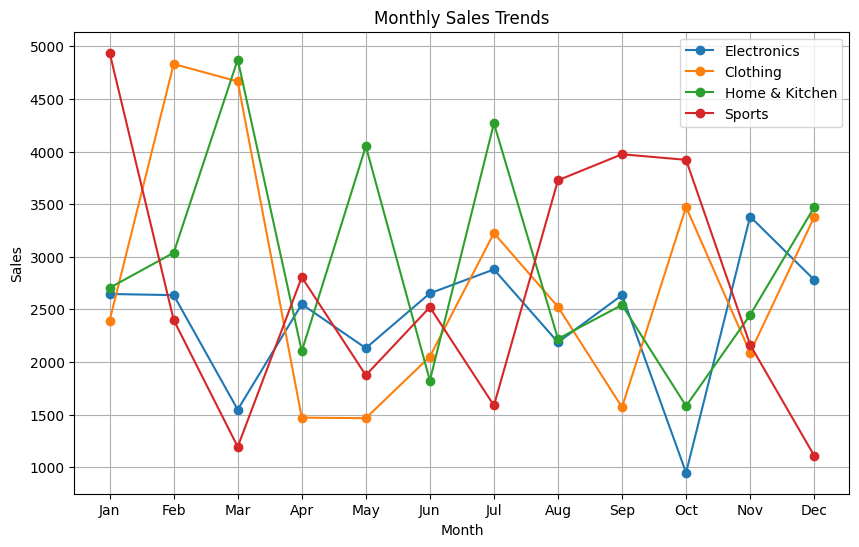

In [14]:
import matplotlib.pyplot as plt

# 1. Monthly Sales Trends (Line Plot)

plt.figure(figsize=(10,6))

for column in columns:
    plt.plot(df.index, df[column], marker='o', label=column)

plt.title("Monthly Sales Trends")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

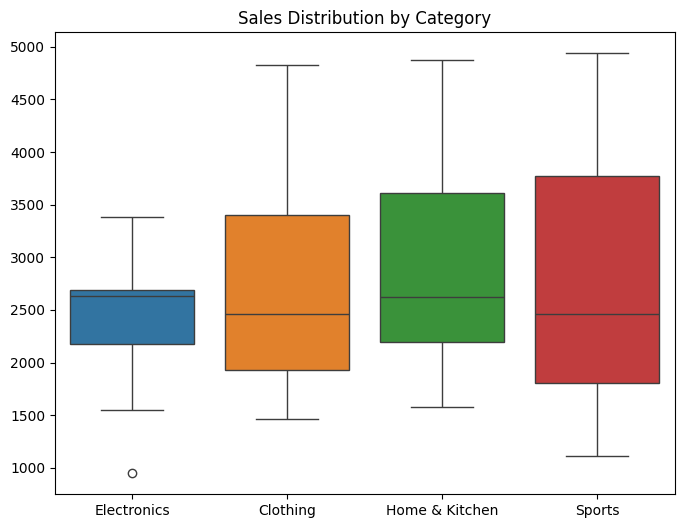

In [15]:
# 2. Box Plot – Sales Distribution
import seaborn as sns
plt.figure(figsize=(8,6))
sns.boxplot(data=df[columns])
plt.title("Sales Distribution by Category")
plt.show()

In [17]:
# i) Element-wise Absolute Value

array = np.array([[1, -2, 3],[-4, 5, -6]])
np.abs(array)

array([[1, 2, 3],
       [4, 5, 6]])

In [18]:
# ii) Percentiles

# Flattened
np.percentile(array.flatten(), [25, 50, 75])

# Column-wise
np.percentile(array, [25, 50, 75], axis=0)

# Row-wise
np.percentile(array, [25, 50, 75], axis=1)

array([[-0.5, -5. ],
       [ 1. , -4. ],
       [ 2. ,  0.5]])

In [19]:
# iii) Mean, Median, Std

# Flattened
print("Mean:", np.mean(array))
print("Median:", np.median(array))
print("Std:", np.std(array))

# Column-wise
print("Column Mean:", np.mean(array, axis=0))
print("Column Median:", np.median(array, axis=0))
print("Column Std:", np.std(array, axis=0))

# Row-wise
print("Row Mean:", np.mean(array, axis=1))
print("Row Median:", np.median(array, axis=1))
print("Row Std:", np.std(array, axis=1))

Mean: -0.5
Median: -0.5
Std: 3.8622100754188224
Column Mean: [-1.5  1.5 -1.5]
Column Median: [-1.5  1.5 -1.5]
Column Std: [2.5 3.5 4.5]
Row Mean: [ 0.66666667 -1.66666667]
Row Median: [ 1. -4.]
Row Std: [2.05480467 4.78423336]


In [20]:
# Q.3 For the array: a = np.array([-1.8, -1.6, -0.5, 0.5,1.6, 1.8, 3.0]).

a = np.array([-1.8, -1.6, -0.5, 0.5, 1.6, 1.8, 3.0])

print("Floor:", np.floor(a))
print("Ceiling:", np.ceil(a))
print("Truncated:", np.trunc(a))
print("Rounded:", np.round(a))

Floor: [-2. -2. -1.  0.  1.  1.  3.]
Ceiling: [-1. -1. -0.  1.  2.  2.  3.]
Truncated: [-1. -1. -0.  0.  1.  1.  3.]
Rounded: [-2. -2. -0.  0.  2.  2.  3.]


In [21]:
# Q.4 WAP to swap two elements in a list in Python Using a Temporary Variable.

lst = [10, 20, 30, 40]

pos1 = 1
pos2 = 3

temp = lst[pos1]
lst[pos1] = lst[pos2]
lst[pos2] = temp

print("Swapped List:", lst)

Swapped List: [10, 40, 30, 20]


In [22]:
# Q.5 Write a Python program to swap two elements in a set by converting it to a list first.

s = {1, 2, 3, 4}

# Convert to list
lst = list(s)

pos1 = 0
pos2 = 2

# Swap
lst[pos1], lst[pos2] = lst[pos2], lst[pos1]

# Convert back to set
s = set(lst)

print("Swapped Set:", s)

Swapped Set: {1, 2, 3, 4}
